In [1]:
import warnings

warnings.filterwarnings("ignore")

import json

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.options.display.float_format = "{:.2f}".format

In [2]:
df = pd.read_csv("data/diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.00,0,1,never,25.19,6.60,140,0
1,Female,54.00,0,0,No Info,27.32,6.60,80,0
2,Male,28.00,0,0,never,27.32,5.70,158,0
3,Female,36.00,0,0,current,23.45,5.00,155,0
4,Male,76.00,1,1,current,20.14,4.80,155,0


In [3]:
duplicate_rows_data = df[df.duplicated()]
print("duplicate rows: ", duplicate_rows_data.shape)

duplicate rows:  (3854, 9)


In [4]:
df = df.drop_duplicates()

In [5]:
# Count unique values of each column
for column in df.columns:
    num_distinct_values = len(df[column].unique())
    print(f"{column}: {num_distinct_values} unique values")

gender: 3 unique values
age: 102 unique values
hypertension: 2 unique values
heart_disease: 2 unique values
smoking_history: 6 unique values
bmi: 4247 unique values
HbA1c_level: 18 unique values
blood_glucose_level: 18 unique values
diabetes: 2 unique values


In [6]:
# Check null values
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [7]:
# Remove Other Gender
df = df[df["gender"] != "Other"]

In [8]:
df.describe().style.format("{:.2f}")

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96128.00,96128.00,96128.00,96128.00,96128.00,96128.00,96128.00
mean,41.80,0.08,0.04,27.32,5.53,138.22,0.09
std,22.46,0.27,0.20,6.77,1.07,40.91,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.40,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,59.00,0.00,0.00,29.86,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


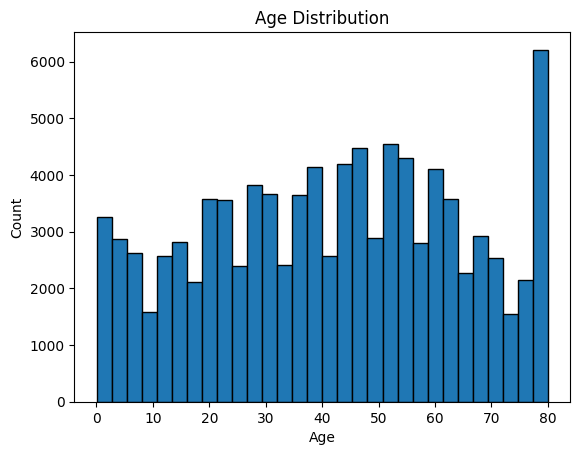

In [9]:
plt.hist(df["age"], bins=30, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

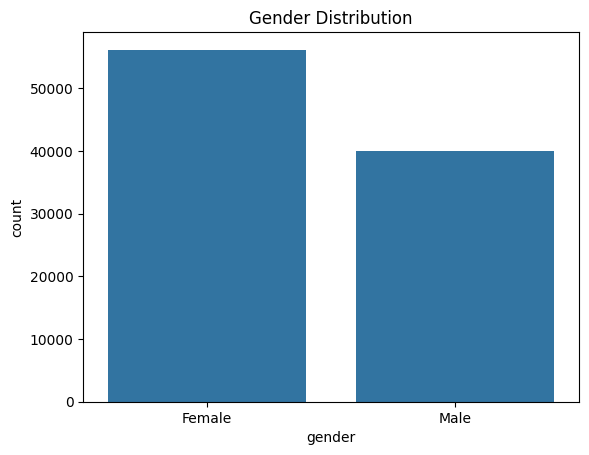

In [10]:
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

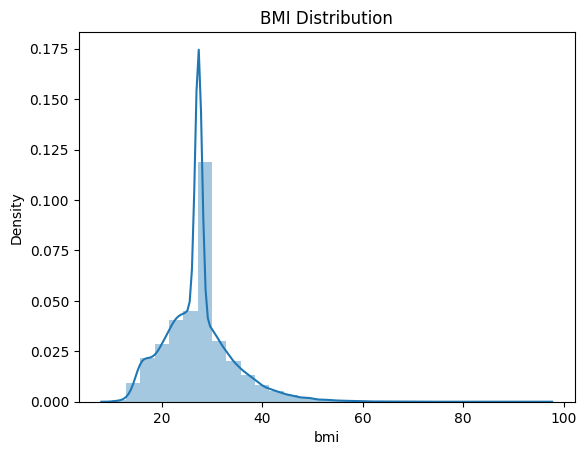

In [11]:
sns.distplot(df["bmi"], bins=30)
plt.title("BMI Distribution")
plt.show()

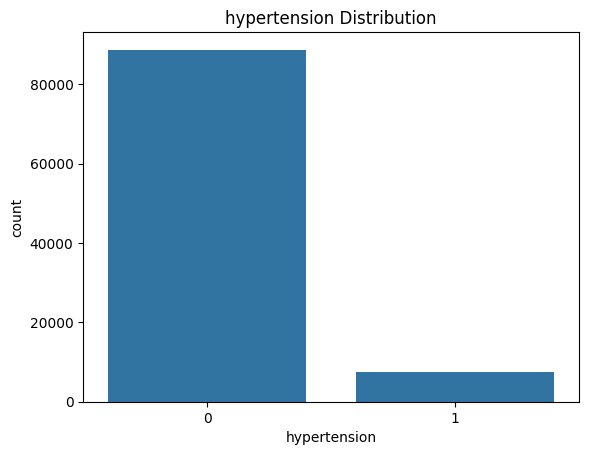

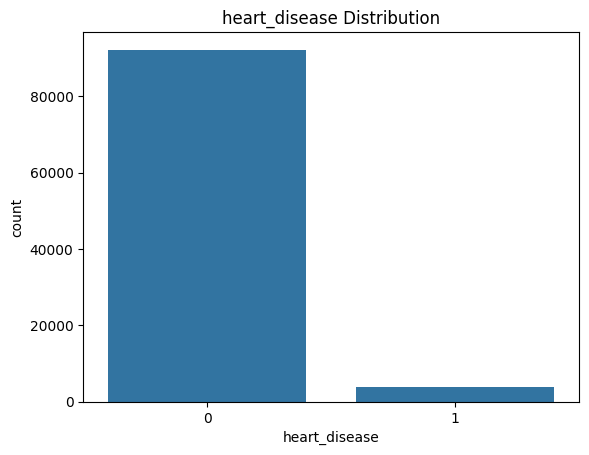

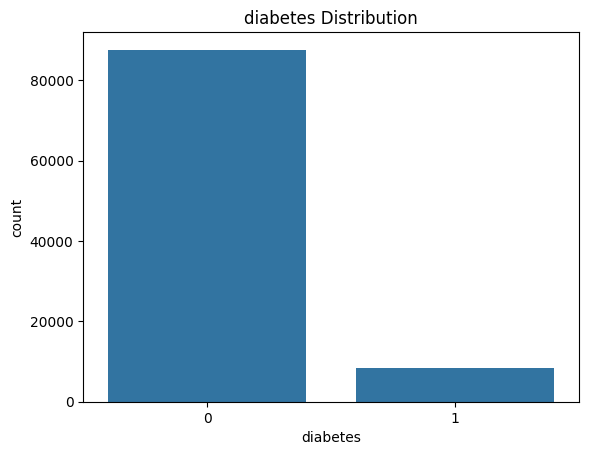

In [12]:
for col in ["hypertension", "heart_disease", "diabetes"]:
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution")
    plt.show()

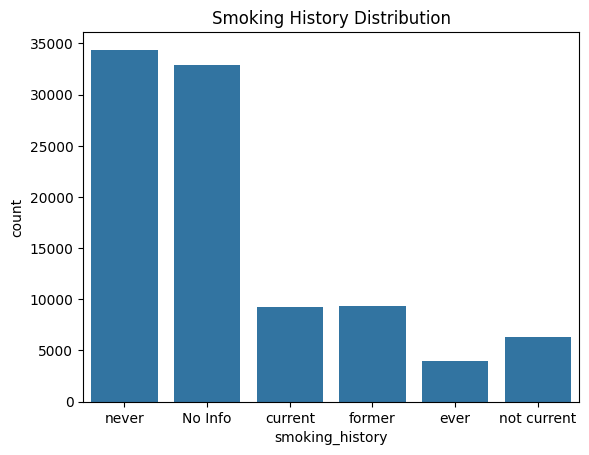

In [13]:
sns.countplot(x="smoking_history", data=df)
plt.title("Smoking History Distribution")
plt.show()

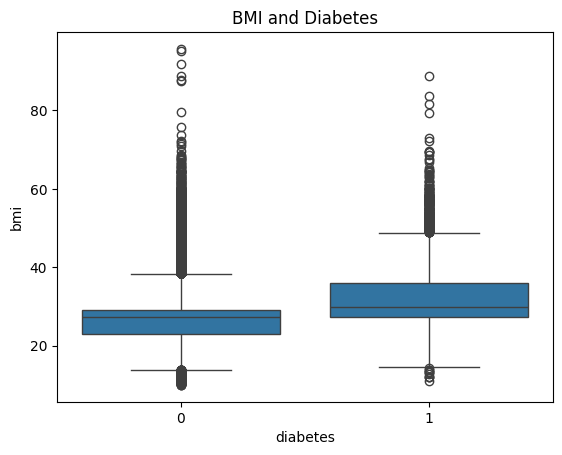

In [14]:
sns.boxplot(x="diabetes", y="bmi", data=df)
plt.title("BMI and Diabetes")
plt.show()

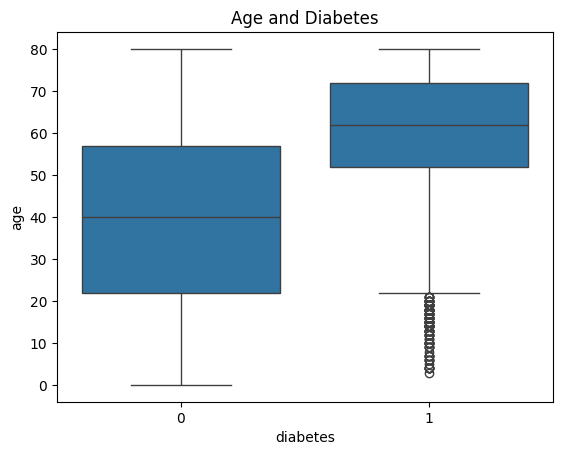

In [15]:
sns.boxplot(x="diabetes", y="age", data=df)
plt.title("Age and Diabetes")
plt.show()

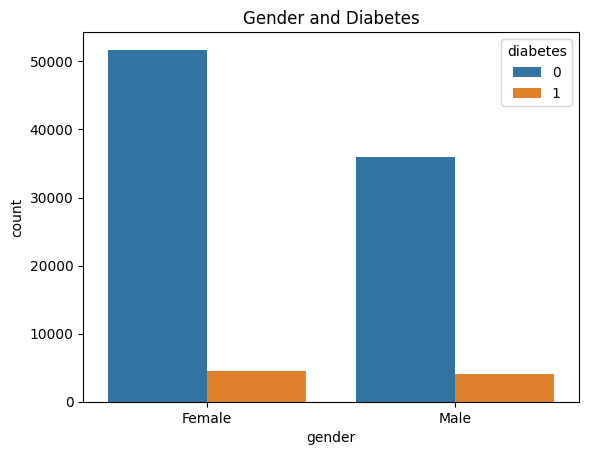

In [16]:
sns.countplot(x="gender", hue="diabetes", data=df)
plt.title("Gender and Diabetes")
plt.show()

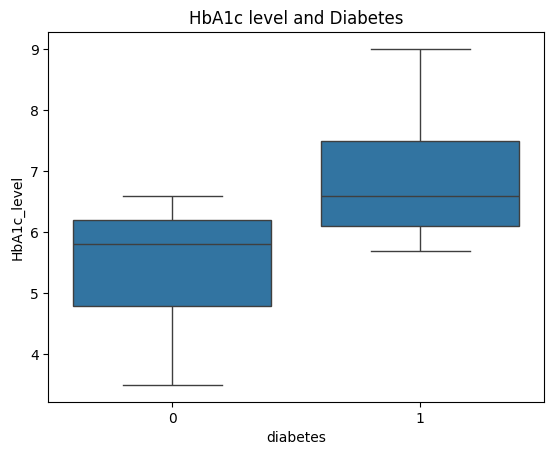

In [17]:
sns.boxplot(x="diabetes", y="HbA1c_level", data=df)
plt.title("HbA1c level and Diabetes")
plt.show()

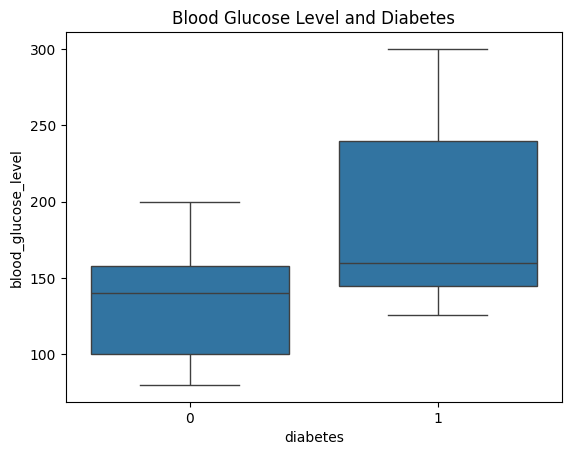

In [18]:
sns.boxplot(x="diabetes", y="blood_glucose_level", data=df)
plt.title("Blood Glucose Level and Diabetes")
plt.show()

In [19]:
def recategorize_smoking(smoking_status):
    if smoking_status in ["never", "No Info"]:
        return "non_smoker"
    elif smoking_status == "current":
        return "current"
    elif smoking_status in ["ever", "former", "not current"]:
        return "past_smoker"


# Apply the function to the 'smoking_history' column
df["smoking_history"] = df["smoking_history"].apply(recategorize_smoking)

# Check the new value counts
print(df["smoking_history"].value_counts())

smoking_history
non_smoker     67276
past_smoker    19655
current         9197
Name: count, dtype: int64


In [20]:
data = df.copy()
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.00,0,1,non_smoker,25.19,6.60,140,0
1,Female,54.00,0,0,non_smoker,27.32,6.60,80,0
2,Male,28.00,0,0,non_smoker,27.32,5.70,158,0
3,Female,36.00,0,0,current,23.45,5.00,155,0
4,Male,76.00,1,1,current,20.14,4.80,155,0


In [21]:
def perform_one_hot_encoding(df, column_name):
    dummies = pd.get_dummies(df[column_name], prefix=column_name, dtype=int)
    # Drop the original column and append the new dummy columns to the dataframe
    df = pd.concat([df.drop(column_name, axis=1), dummies], axis=1)

    return df


# Perform one-hot encoding on the gender variable
data = perform_one_hot_encoding(data, "gender")

# Perform one-hot encoding on the smoking history variable
data = perform_one_hot_encoding(data, "smoking_history")

In [22]:
data.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,smoking_history_current,smoking_history_non_smoker,smoking_history_past_smoker
0,80.00,0,1,25.19,6.60,140,0,1,0,0,1,0
1,54.00,0,0,27.32,6.60,80,0,1,0,0,1,0
2,28.00,0,0,27.32,5.70,158,0,0,1,0,1,0
3,36.00,0,0,23.45,5.00,155,0,1,0,1,0,0
4,76.00,1,1,20.14,4.80,155,0,0,1,1,0,0


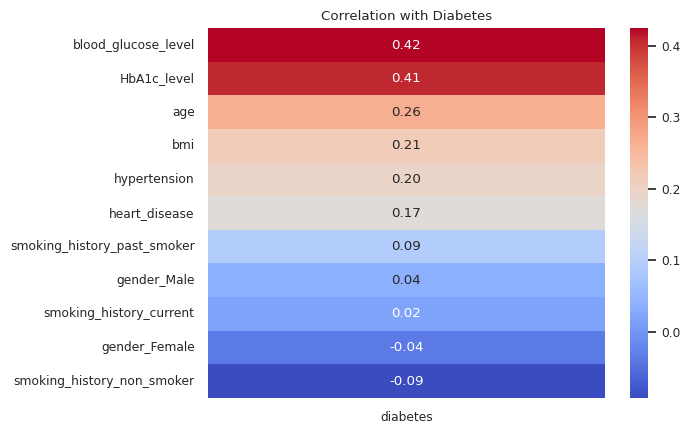

In [23]:
corr = data.corr()
target_corr = corr["diabetes"].drop("diabetes")

# Sort correlation values in descending order
target_corr_sorted = target_corr.sort_values(ascending=False)

sns.set(font_scale=0.8)
sns.set_style("white")
sns.set_palette("PuBuGn_d")
sns.heatmap(target_corr_sorted.to_frame(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation with Diabetes")
plt.show()

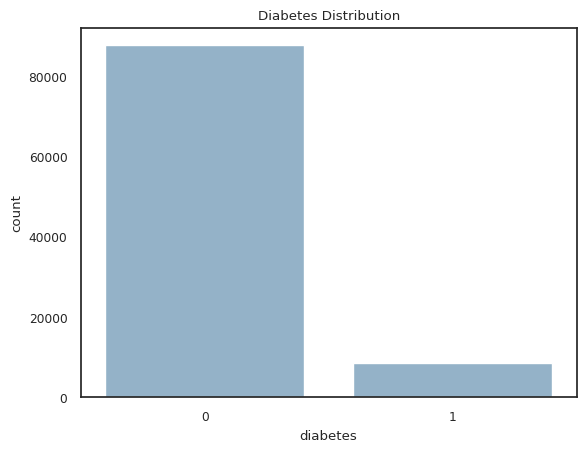

In [24]:
sns.countplot(x="diabetes", data=df)
plt.title("Diabetes Distribution")
plt.show()

In [25]:
over = SMOTE(sampling_strategy=0.1)
under = RandomUnderSampler(sampling_strategy=0.5)

In [26]:
# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            [
                "age",
                "bmi",
                "HbA1c_level",
                "blood_glucose_level",
                "hypertension",
                "heart_disease",
            ],
        ),
        ("cat", OneHotEncoder(), ["gender", "smoking_history"]),
    ]
)

# Split data into features and target variable
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [27]:
# Create a pipeline that preprocesses the data, resamples data, and then trains a classifier
clf = imbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("over", over),
        ("under", under),
        ("classifier", RandomForestClassifier()),
    ]
)

In [28]:
# Define the hyperparameters and the values we want to test
param_grid = {
    "classifier__n_estimators": [100],
    "classifier__max_depth": [10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
}

In [29]:
# Create Grid Search object
grid_search = GridSearchCV(clf, param_grid, cv=7)

# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
grid_search.fit(X_train, y_train)

# Print the best parameters
print("Best Parameters: ", grid_search.best_params_)

Best Parameters:  {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


Model Accuracy:  0.9487152813897847
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     17525
           1       0.68      0.80      0.73      1701

    accuracy                           0.95     19226
   macro avg       0.83      0.88      0.85     19226
weighted avg       0.95      0.95      0.95     19226



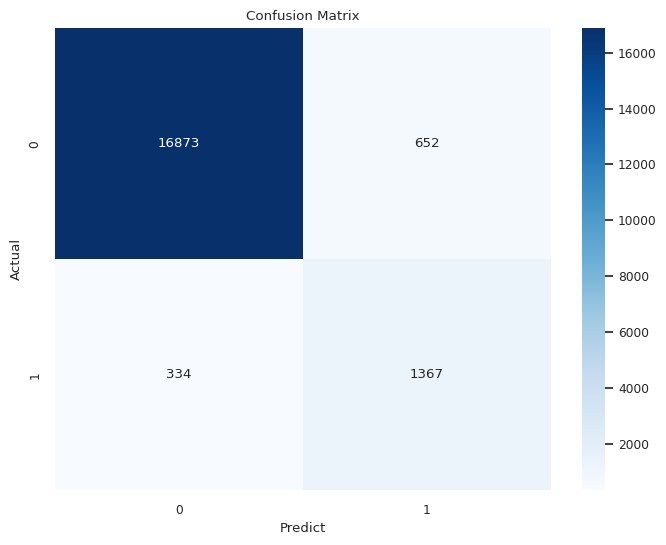

In [30]:
y_pred = grid_search.predict(X_test)

# Evaluate the model
print("Model Accuracy: ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("Actual")
plt.show()

In [31]:
joblib.dump(grid_search.best_estimator_, "artifacts/diabetes_100k_rf_model.pkl")
schema = {
    "features": list(X.columns),
    "dtypes": {col: str(dtype) for col, dtype in X.dtypes.items()},
    "target": "diabetes",
}

with open("artifacts/diabetes_100k_rf_schema.json", "w") as f:
    json.dump(schema, f, indent=4)
